## Task 1: Designing a Heuristic for a Warehouse Robot

The heuristic is the Euclidean straight-line distance to `Packing_Station`. It is suitable because the locations have 2D coordinates and straight-line distance estimates the remaining spatial separation. The edge-by-edge consistency check also reveals the effect of edge costs rounded to one decimal place.

,Location,h(n)
0,Receiving_Area,9.220
1,Storage_A,7.071
2,Storage_B,6.325
3,Sorting_Area,5.000
4,Inspection_Area,2.236
5,Packing_Station,0.000


,Edge,h(n),cost + h(m),Consistent?
0,Receiving_Area -> Storage_A,9.220,9.271,True
1,Receiving_Area -> Storage_B,9.220,10.425,True
2,Storage_A -> Sorting_Area,7.071,7.200,True
3,Storage_B -> Inspection_Area,6.325,7.236,True
4,Storage_B -> Sorting_Area,6.325,11.000,True
5,Sorting_Area -> Inspection_Area,5.000,5.436,True
6,Sorting_Area -> Packing_Station,5.000,5.000,True
7,Inspection_Area -> Packing_Station,2.236,2.200,False


Minimum-cost path: Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


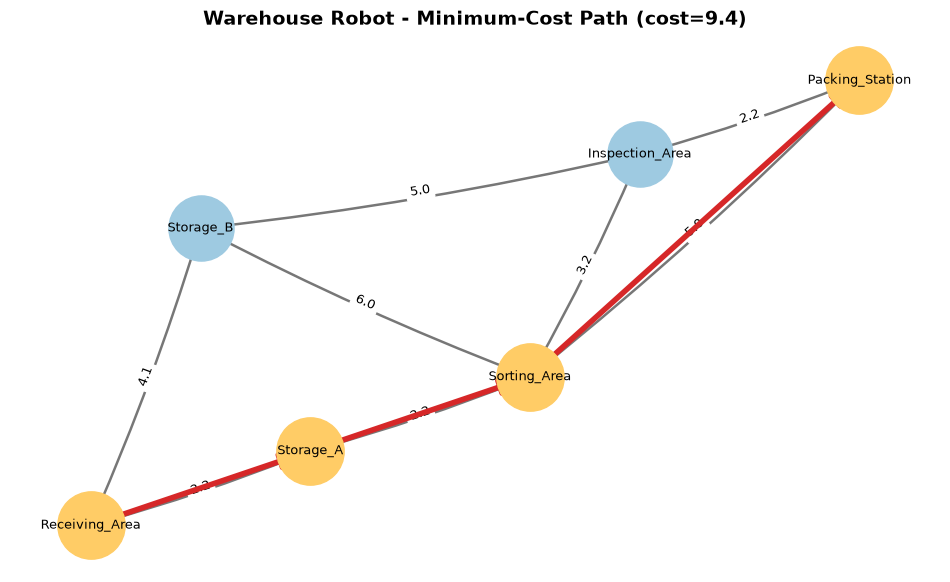

In [1]:
import math
import heapq
from itertools import count

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd


def euclidean(locations, current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.hypot(x2 - x1, y2 - y1)


def path_cost(graph, path):
    return sum(graph[a][b] for a, b in zip(path, path[1:]))


def draw_weighted_graph(graph, locations, path=None, title="Weighted graph", ax=None):
    G = nx.DiGraph()
    for node in locations:
        G.add_node(node)
    for node, neighbors in graph.items():
        for neighbor, cost in neighbors.items():
            G.add_edge(node, neighbor, weight=cost)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 7))

    nx.draw_networkx_nodes(G, locations, node_color="#9ecae1", node_size=2200, ax=ax)
    nx.draw_networkx_labels(G, locations, font_size=9, ax=ax)
    nx.draw_networkx_edges(
        G, locations, edge_color="#777777", width=1.8,
        arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.03", ax=ax
    )
    nx.draw_networkx_edge_labels(
        G, locations, edge_labels=nx.get_edge_attributes(G, "weight"),
        font_size=9, label_pos=0.5, ax=ax
    )

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_nodes(
            G, locations, nodelist=path, node_color="#ffcc66", node_size=2350, ax=ax
        )
        nx.draw_networkx_edges(
            G, locations, edgelist=path_edges, edge_color="#d62728",
            width=4, arrows=True, arrowsize=24, ax=ax
        )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    return G


warehouse_locations = {
    "Receiving_Area": (0, 0), "Storage_A": (2, 1), "Storage_B": (1, 4),
    "Sorting_Area": (4, 2), "Inspection_Area": (5, 5), "Packing_Station": (7, 6)
}

warehouse_graph = {
    "Receiving_Area": {"Storage_A": 2.2, "Storage_B": 4.1},
    "Storage_A": {"Sorting_Area": 2.2},
    "Storage_B": {"Inspection_Area": 5.0, "Sorting_Area": 6.0},
    "Sorting_Area": {"Inspection_Area": 3.2, "Packing_Station": 5.0},
    "Inspection_Area": {"Packing_Station": 2.2},
    "Packing_Station": {}
}

warehouse_goal = "Packing_Station"
heuristic_table = pd.DataFrame([
    {"Location": node, "h(n)": round(euclidean(warehouse_locations, node, warehouse_goal), 3)}
    for node in warehouse_locations
])
display(heuristic_table)

consistency_rows = []
for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        h_node = euclidean(warehouse_locations, node, warehouse_goal)
        rhs = cost + euclidean(warehouse_locations, neighbor, warehouse_goal)
        consistency_rows.append({
            "Edge": f"{node} -> {neighbor}", "h(n)": round(h_node, 3),
            "cost + h(m)": round(rhs, 3), "Consistent?": h_node <= rhs + 1e-12
        })
display(pd.DataFrame(consistency_rows))

warehouse_nx = nx.DiGraph()
for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        warehouse_nx.add_edge(node, neighbor, weight=cost)
warehouse_path = nx.shortest_path(
    warehouse_nx, "Receiving_Area", warehouse_goal, weight="weight"
)
warehouse_cost = nx.shortest_path_length(
    warehouse_nx, "Receiving_Area", warehouse_goal, weight="weight"
)
print("Minimum-cost path:", " -> ".join(warehouse_path))
print(f"Total cost: {warehouse_cost:.2f}")
draw_weighted_graph(
    warehouse_graph, warehouse_locations, warehouse_path,
    f"Warehouse Robot - Minimum-Cost Path (cost={warehouse_cost:.1f})"
)
plt.show()

**Observation.** Euclidean distance is appropriate because it reflects direct spatial separation and normally lower-bounds travel through corridors. All listed edges satisfy consistency except `Inspection_Area -> Packing_Station`. That tiny violation occurs because the document rounds the exact Euclidean cost √5 ≈ 2.236 down to 2.2. With the exact edge cost, equality would hold.

## Task 2: Greedy Best-First Search for Airport Baggage Handling

GBFS prioritizes only `h(n)`, so it always expands the frontier node that appears closest to the departure gate.

Expansion order: Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Solution path: Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Total path cost: 12.30


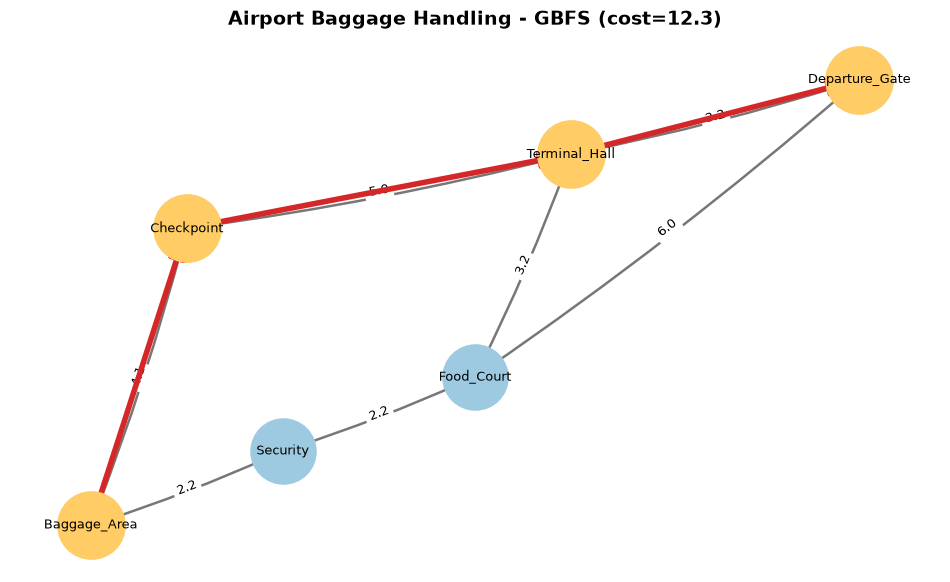

In [2]:
airport_locations = {
    "Baggage_Area": (0, 0), "Security": (2, 1), "Checkpoint": (1, 4),
    "Food_Court": (4, 2), "Terminal_Hall": (5, 5), "Departure_Gate": (8, 6)
}

airport_graph = {
    "Baggage_Area": {"Security": 2.2, "Checkpoint": 4.1},
    "Security": {"Food_Court": 2.2},
    "Checkpoint": {"Terminal_Hall": 5.0},
    "Food_Court": {"Terminal_Hall": 3.2, "Departure_Gate": 6.0},
    "Terminal_Hall": {"Departure_Gate": 3.2},
    "Departure_Gate": {}
}


def gbfs(graph, locations, start, goal):
    frontier = [(euclidean(locations, start, goal), 0, start)]
    sequence = count(1)
    came_from = {start: None}
    explored = set()
    expansion_order = []

    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in explored:
            continue
        explored.add(current)
        expansion_order.append(current)

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            path.reverse()
            return path, path_cost(graph, path), expansion_order

        for neighbor in graph[current]:
            if neighbor not in explored and neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(
                    frontier,
                    (euclidean(locations, neighbor, goal), next(sequence), neighbor)
                )
    return None, math.inf, expansion_order


airport_path, airport_cost, airport_expansion = gbfs(
    airport_graph, airport_locations, "Baggage_Area", "Departure_Gate"
)
print("Expansion order:", " -> ".join(airport_expansion))
print("Solution path:", " -> ".join(airport_path))
print(f"Total path cost: {airport_cost:.2f}")
draw_weighted_graph(
    airport_graph, airport_locations, airport_path,
    f"Airport Baggage Handling - GBFS (cost={airport_cost:.1f})"
)
plt.show()

GBFS expands `Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate` and returns a path cost of 12.3. At each step, the selected node has the smallest Euclidean distance to the goal among frontier nodes. It prefers `Checkpoint` over `Security`, then `Terminal_Hall`, because those nodes appear closer to the departure gate; accumulated route cost is not part of the ranking.

## Task 3: A* Search for an Emergency Supply Robot

A* prioritizes `f(n) = g(n) + h(n)`, combining the actual cost already paid with the estimated remaining distance.

Expansion order: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
Solution path: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
Total path cost: 10.40


,Node,g(n),h(n),f(n)
0,Pharmacy,0.0,10.000,10.000
1,Main_Corridor,2.2,7.810,10.010
2,Nursing_Station,4.4,5.657,10.057
3,Emergency_Ward,10.4,0.000,10.400


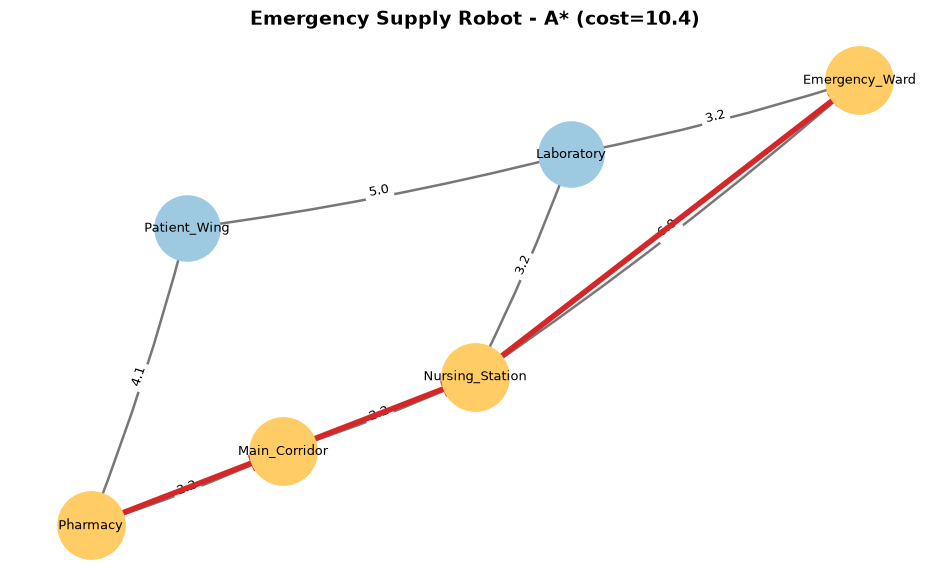

In [3]:
hospital_locations = {
    "Pharmacy": (0, 0), "Main_Corridor": (2, 1), "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2), "Laboratory": (5, 5), "Emergency_Ward": (8, 6)
}

hospital_graph = {
    "Pharmacy": {"Main_Corridor": 2.2, "Patient_Wing": 4.1},
    "Main_Corridor": {"Nursing_Station": 2.2},
    "Patient_Wing": {"Laboratory": 5.0},
    "Nursing_Station": {"Laboratory": 3.2, "Emergency_Ward": 6.0},
    "Laboratory": {"Emergency_Ward": 3.2},
    "Emergency_Ward": {}
}


def a_star(graph, locations, start, goal, weight=1.0):
    sequence = count()
    frontier = [(weight * euclidean(locations, start, goal), next(sequence), start)]
    came_from = {start: None}
    g_cost = {node: math.inf for node in graph}
    g_cost[start] = 0.0
    closed = set()
    expansion_order = []

    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in closed:
            continue
        closed.add(current)
        expansion_order.append(current)

        if current == goal:
            path = []
            cursor = current
            while cursor is not None:
                path.append(cursor)
                cursor = came_from[cursor]
            path.reverse()
            return path, g_cost[current], expansion_order, g_cost

        for neighbor, edge_cost in graph[current].items():
            tentative_g = g_cost[current] + edge_cost
            if tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                priority = tentative_g + weight * euclidean(locations, neighbor, goal)
                heapq.heappush(frontier, (priority, next(sequence), neighbor))
    return None, math.inf, expansion_order, g_cost


hospital_path, hospital_cost, hospital_expansion, hospital_g = a_star(
    hospital_graph, hospital_locations, "Pharmacy", "Emergency_Ward"
)
print("Expansion order:", " -> ".join(hospital_expansion))
print("Solution path:", " -> ".join(hospital_path))
print(f"Total path cost: {hospital_cost:.2f}")

hospital_rows = []
for node in hospital_expansion:
    g = hospital_g[node]
    h = euclidean(hospital_locations, node, "Emergency_Ward")
    hospital_rows.append({"Node": node, "g(n)": round(g, 3), "h(n)": round(h, 3), "f(n)": round(g+h, 3)})
display(pd.DataFrame(hospital_rows))

draw_weighted_graph(
    hospital_graph, hospital_locations, hospital_path,
    f"Emergency Supply Robot - A* (cost={hospital_cost:.1f})"
)
plt.show()

Unlike GBFS, A* can reject a node that looks geographically close when reaching it has already been expensive. Here it expands `Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward` and returns cost 10.4. The `g(n)` term makes the choice reflect estimated total route cost rather than apparent closeness alone.

## Task 4: Weighted A* for an Autonomous Delivery Drone

Weighted A* uses `f(n) = g(n) + w h(n)`. Increasing `w` gives the heuristic more influence and can reduce expansions, but for `w > 1` the normal optimality guarantee is lost.

,Weight w,Solution Path,Total Cost,Nodes Expanded,Expansion Order
0,1.0,Distribution_Center -> Zone_A -> Zone_C -> Cus...,10.4,5,Distribution_Center -> Zone_A -> Zone_C -> Zon...
1,1.5,Distribution_Center -> Zone_A -> Zone_C -> Cus...,10.4,4,Distribution_Center -> Zone_A -> Zone_C -> Cus...
2,2.0,Distribution_Center -> Zone_B -> Zone_D -> Cus...,11.2,4,Distribution_Center -> Zone_B -> Zone_D -> Cus...
3,3.0,Distribution_Center -> Zone_B -> Zone_D -> Cus...,11.2,4,Distribution_Center -> Zone_B -> Zone_D -> Cus...


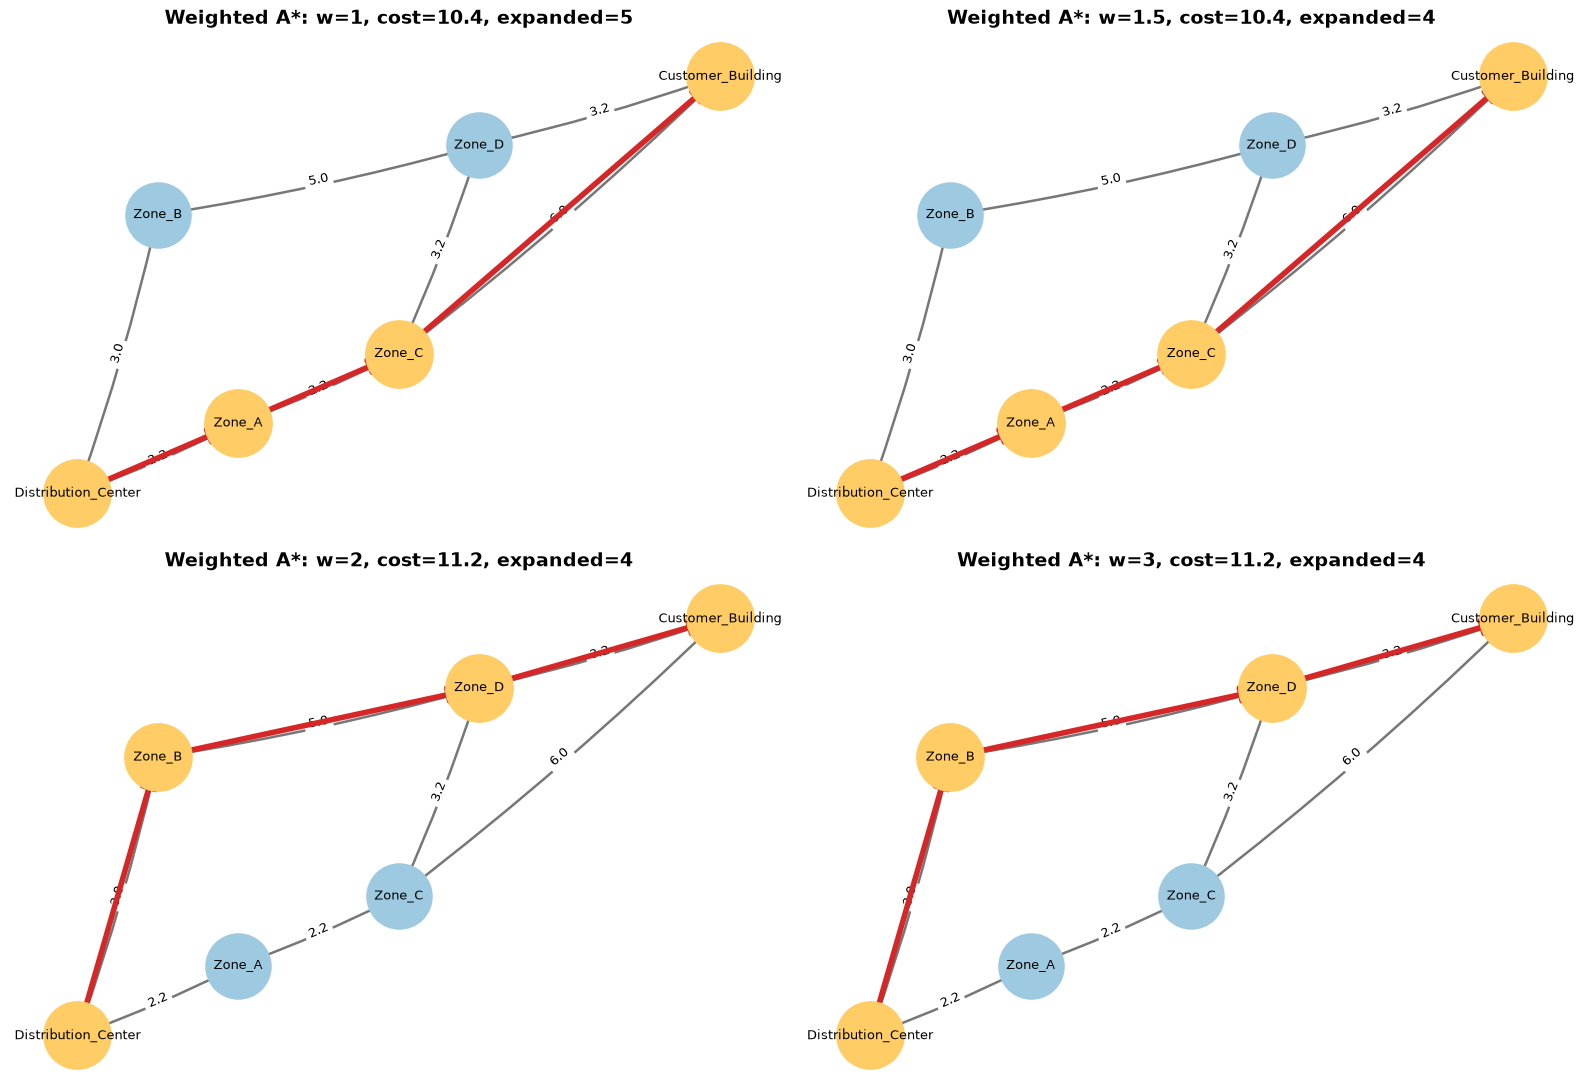

In [4]:
drone_locations = {
    "Distribution_Center": (0, 0), "Zone_A": (2, 1), "Zone_B": (1, 4),
    "Zone_C": (4, 2), "Zone_D": (5, 5), "Customer_Building": (8, 6)
}

drone_graph = {
    "Distribution_Center": {"Zone_A": 2.2, "Zone_B": 3.0},
    "Zone_A": {"Zone_C": 2.2},
    "Zone_B": {"Zone_D": 5.0},
    "Zone_C": {"Zone_D": 3.2, "Customer_Building": 6.0},
    "Zone_D": {"Customer_Building": 3.2},
    "Customer_Building": {}
}

weights = [1, 1.5, 2, 3]
weighted_results = []
weighted_paths = {}

for w in weights:
    path, cost_value, expanded, _ = a_star(
        drone_graph, drone_locations, "Distribution_Center", "Customer_Building", weight=w
    )
    weighted_paths[w] = path
    weighted_results.append({
        "Weight w": w, "Solution Path": " -> ".join(path),
        "Total Cost": round(cost_value, 2), "Nodes Expanded": len(expanded),
        "Expansion Order": " -> ".join(expanded)
    })

weighted_df = pd.DataFrame(weighted_results)
display(weighted_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, row in zip(axes.flat, weighted_results):
    w = row["Weight w"]
    draw_weighted_graph(
        drone_graph, drone_locations, weighted_paths[w],
        f"Weighted A*: w={w}, cost={row['Total Cost']}, expanded={row['Nodes Expanded']}", ax=ax
    )
plt.tight_layout()
plt.show()

For `w = 1` and `w = 1.5`, the algorithm returns the lower-cost route through `Zone_A` and `Zone_C` (cost 10.4). For `w = 2` and `w = 3`, it trusts apparent proximity more strongly, expands fewer nodes, and returns the route through `Zone_B` and `Zone_D` (cost 11.2). Thus a larger weight trades solution quality guarantees for more aggressive goal-directed search.